In [1]:
# Cell 1: Import Libraries and Load Data
from datasets import load_from_disk
import json
import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")

baseline_path = "/content/drive/MyDrive/vlm-finetuning-project1/results/baseline_test_full_2b_second/repair_applied/predictions_repaired.jsonl"
sft_path = "/content/drive/MyDrive/vlm-finetuning-project1/results/inference/unified-sft-v1_test/repair_applied/predictions_repaired.jsonl"
dataset_path = "/content/drive/MyDrive/vlm-finetuning-project1/datasets/processed"

def load_jsonl(path):
    """Safely loads a JSONL file."""
    data = []
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    data.append(json.loads(line))
        return data
    else:
        print(f"WARNING: Path not found - {path}")
        return []

print("Loading data...")
ds = load_from_disk(dataset_path)["test"]
baseline_data = load_jsonl(baseline_path)
sft_data = load_jsonl(sft_path)

print(f"Loaded {len(ds)} Ground Truth samples.")
print(f"Loaded {len(baseline_data)} Baseline predictions.")
print(f"Loaded {len(sft_data)} SFT predictions.")

Loading data...
Loaded 3004 Ground Truth samples.
Loaded 3004 Baseline predictions.
Loaded 3004 SFT predictions.


In [5]:
# Cell 2: Advanced Regex Parser & Stats Engine

def get_parsed_dict(row):
    """
    Hunts for the JSON block and strips out markdown backticks/artifacts.
    """
    # If Ground Truth, return row directly
    if "raw_output" not in row:
        return row

    raw = row["raw_output"]
    if isinstance(raw, dict):
        return raw

    if not isinstance(raw, str):
        return {}

    cleaned_raw = raw.strip()

    # 1. Regex to extract purely what is inside { }
    dict_match = re.search(r'(\{.*\})', cleaned_raw, re.DOTALL)
    if dict_match:
        cleaned_raw = dict_match.group(1)

    # 2. Try parsing the extracted block
    try:
        return json.loads(cleaned_raw, strict=False)
    except Exception:
        pass

    # 3. Fallback: aggressive escape cleaning
    try:
        escaped = cleaned_raw.replace("\\'", "'").replace('\\"', '"')
        return json.loads(escaped, strict=False)
    except Exception:
        pass

    # 4. Final Fallback
    try:
        return ast.literal_eval(cleaned_raw)
    except Exception:
        pass

    return {}

def get_word_count(text):
    if not text or not isinstance(text, str):
        return 0
    return len(text.split())

def calculate_stats(name, lengths_list):
    if not lengths_list:
        return {"Dataset": name, "Count": 0, "Mean": 0, "Std": 0, "Min": 0,
                "25th": 0, "Median": 0, "75th": 0, "90th": 0, "99th": 0, "Max": 0}

    arr = np.array(lengths_list)
    return {
        "Dataset": name,
        "Count": len(arr),
        "Mean": np.mean(arr),
        "Std": np.std(arr),
        "Min": np.min(arr),
        "25th": np.percentile(arr, 25),
        "Median": np.median(arr),
        "75th": np.percentile(arr, 75),
        "90th": np.percentile(arr, 90),
        "99th": np.percentile(arr, 99),
        "Max": np.max(arr)
    }

def format_stats_df(stats_list):
    df = pd.DataFrame(stats_list).set_index("Dataset")
    for col in df.columns:
        if col not in ["Count", "Min", "Max"]:
            df[col] = df[col].map("{:.1f}".format)
    return df

In [40]:
baseline_data[0]

{'image_id': '0000051',
 'raw_output': '{"caption": "A close-up view of a yellow excavator operating amidst a pile of large rocks on a construction site. The machine is positioned with its bucket engaged in digging through rubble. There are no visible workers in the frame, but there\'s a worker wearing a white hard hat who appears to be near the machinery.", "rule_1_violation": {"reason": "The worker is not present in the scene.", "bounding_box": [[567.0, 89.0, 898.0, 898.0]]}, "rule_2_violation": null, "rule_3_violation": null, "rule_4_violation": null, "excavator": [[567.0, 89.0, 898.0, 898.0]], "rebar": [], "worker_with_white_hard_hat": [[567.0, 89.0, 898.0, 898.0]]}',
 'sample': {'image_id': '0000051',
  'image_caption': 'The bucket of an excavator is shoveling rocks.',
  'illumination': 'normal lighting',
  'camera_distance': 'mid distance',
  'view': 'elevation view',
  'quality_of_info': 'poor info',
  'rule_1_violation': None,
  'rule_2_violation': None,
  'rule_3_violation': N

=== IMAGE CAPTION WORD COUNT STATISTICS ===


,Count,Mean,Std,Min,25th,Median,75th,90th,99th,Max
Dataset,,,,,,,,,,
Ground Truth,3004,48.5,29.8,2,25.0,44.0,68.0,90.0,129.0,163
Baseline (2B),3004,57.5,15.0,17,47.0,56.0,67.0,76.0,102.0,135
SFT LoRA,3004,27.6,8.7,10,21.0,27.0,33.0,39.0,53.0,68


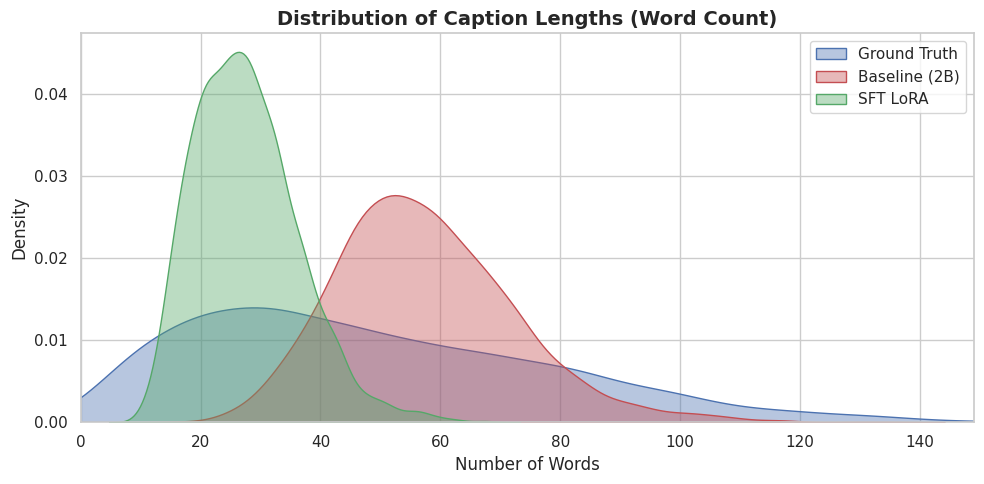

In [41]:
# Cell 3: Image Caption Statistics & Distribution

gt_cap_lens, base_cap_lens, sft_cap_lens = [], [], []

for x in ds:
    c = get_word_count(get_parsed_dict(x).get("image_caption"))
    if c > 0: gt_cap_lens.append(c)

for x in baseline_data:
    c = get_word_count(get_parsed_dict(x).get("caption"))
    if c > 0: base_cap_lens.append(c)

for x in sft_data:
    c = get_word_count(get_parsed_dict(x).get("caption"))
    if c > 0: sft_cap_lens.append(c)

cap_stats = [
    calculate_stats("Ground Truth", gt_cap_lens),
    calculate_stats("Baseline (2B)", base_cap_lens),
    calculate_stats("SFT LoRA", sft_cap_lens)
]

print("=== IMAGE CAPTION WORD COUNT STATISTICS ===")
display(format_stats_df(cap_stats))

plt.figure(figsize=(10, 5))
if gt_cap_lens: sns.kdeplot(gt_cap_lens, label="Ground Truth", fill=True, color="#4C72B0", alpha=0.4)
if base_cap_lens: sns.kdeplot(base_cap_lens, label="Baseline (2B)", fill=True, color="#C44E52", alpha=0.4)
if sft_cap_lens: sns.kdeplot(sft_cap_lens, label="SFT LoRA", fill=True, color="#55A868", alpha=0.4)

plt.title("Distribution of Caption Lengths (Word Count)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Density")

all_99ths = [np.percentile(l, 99) for l in [gt_cap_lens, base_cap_lens, sft_cap_lens] if l]
if all_99ths:
    plt.xlim(0, max(all_99ths) + 20)

plt.legend()
plt.tight_layout()
plt.show()

=== OVERALL REASONING TEXT WORD COUNT STATISTICS ===


,Count,Mean,Std,Min,25th,Median,75th,90th,99th,Max
Dataset,,,,,,,,,,
Ground Truth,435,13.3,4.4,6,11.0,12.0,15.0,19.0,28.7,35
Baseline (2B),2947,27.0,12.6,5,17.0,26.0,35.0,43.0,60.0,84
SFT LoRA,158,10.7,1.9,6,10.0,10.0,12.0,13.0,16.4,17


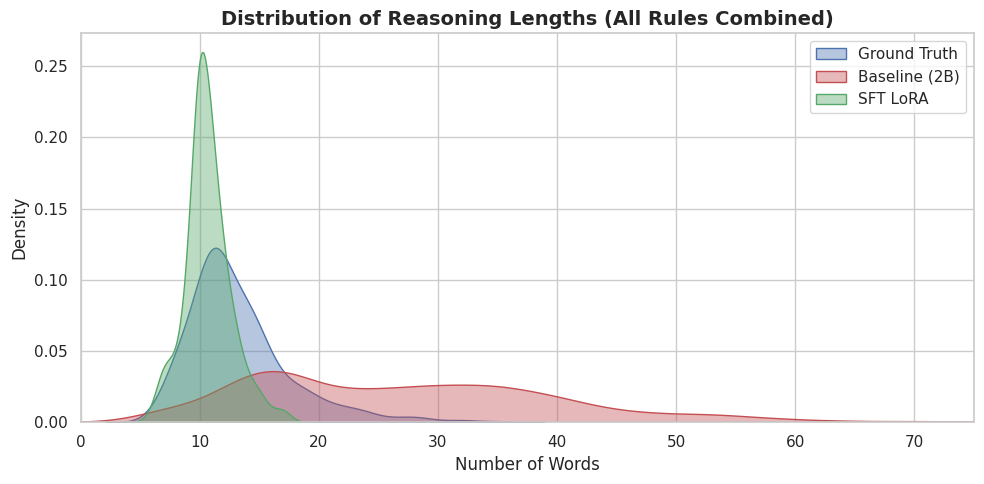

In [42]:
# Cell 4: Overall Safety Violation Reasoning Statistics

rules = ["rule_1_violation", "rule_2_violation", "rule_3_violation", "rule_4_violation"]

def extract_all_reasons(dataset, is_gt=False):
    lens = []
    for x in dataset:
        parsed = x if is_gt else get_parsed_dict(x)
        for r in rules:
            v = parsed.get(r)
            if v and isinstance(v, dict) and "reason" in v:
                c = get_word_count(v.get("reason"))
                if c > 0: lens.append(c)
    return lens

gt_reason_lens = extract_all_reasons(ds, is_gt=True)
base_reason_lens = extract_all_reasons(baseline_data)
sft_reason_lens = extract_all_reasons(sft_data)

reason_stats = [
    calculate_stats("Ground Truth", gt_reason_lens),
    calculate_stats("Baseline (2B)", base_reason_lens),
    calculate_stats("SFT LoRA", sft_reason_lens)
]

print("=== OVERALL REASONING TEXT WORD COUNT STATISTICS ===")
display(format_stats_df(reason_stats))

plt.figure(figsize=(10, 5))
if gt_reason_lens: sns.kdeplot(gt_reason_lens, label="Ground Truth", fill=True, color="#4C72B0", alpha=0.4)
if base_reason_lens: sns.kdeplot(base_reason_lens, label="Baseline (2B)", fill=True, color="#C44E52", alpha=0.4)
if sft_reason_lens: sns.kdeplot(sft_reason_lens, label="SFT LoRA", fill=True, color="#55A868", alpha=0.4)

plt.title("Distribution of Reasoning Lengths (All Rules Combined)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Density")

all_reason_99ths = [np.percentile(l, 99) for l in [gt_reason_lens, base_reason_lens, sft_reason_lens] if l]
if all_reason_99ths:
    plt.xlim(0, max(all_reason_99ths) + 15)

plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# Cell 5: Reasoning Statistics Segmented by Specific Safety Rule

def extract_rule_reasons(dataset, rule_key, is_gt=False):
    lens = []
    for x in dataset:
        parsed = x if is_gt else get_parsed_dict(x)
        v = parsed.get(rule_key)
        if v and isinstance(v, dict) and "reason" in v:
            c = get_word_count(v.get("reason"))
            if c > 0: lens.append(c)
    return lens

for r in rules:
    print(f"\n=== {r.upper().replace('_', ' ')} ===")

    gt_rule_lens = extract_rule_reasons(ds, r, is_gt=True)
    base_rule_lens = extract_rule_reasons(baseline_data, r)
    sft_rule_lens = extract_rule_reasons(sft_data, r)

    rule_stats = [
        calculate_stats("Ground Truth", gt_rule_lens),
        calculate_stats("Baseline (2B)", base_rule_lens),
        calculate_stats("SFT LoRA", sft_rule_lens)
    ]

    display(format_stats_df(rule_stats))


=== RULE 1 VIOLATION ===


,Count,Mean,Std,Min,25th,Median,75th,90th,99th,Max
Dataset,,,,,,,,,,
Ground Truth,323,13.6,4.6,6,11.0,12.0,15.0,19.0,29.0,35
Baseline (2B),2937,27.0,12.6,5,17.0,26.0,35.0,43.0,60.0,84
SFT LoRA,142,10.5,1.8,6,10.0,10.0,11.0,12.9,16.2,17



=== RULE 2 VIOLATION ===


,Count,Mean,Std,Min,25th,Median,75th,90th,99th,Max
Dataset,,,,,,,,,,
Ground Truth,25,14.0,3.5,7,11.0,14.0,17.0,18.2,20.0,20
Baseline (2B),3,26.3,6.0,18,23.5,29.0,30.5,31.4,31.9,32
SFT LoRA,14,12.6,1.3,10,12.0,13.0,13.0,13.7,15.7,16



=== RULE 3 VIOLATION ===


,Count,Mean,Std,Min,25th,Median,75th,90th,99th,Max
Dataset,,,,,,,,,,
Ground Truth,63,10.3,1.9,7,9.0,10.0,11.0,12.0,15.8,17
Baseline (2B),2,26.0,1.0,25,25.5,26.0,26.5,26.8,27.0,27
SFT LoRA,2,9.0,0.0,9,9.0,9.0,9.0,9.0,9.0,9



=== RULE 4 VIOLATION ===


,Count,Mean,Std,Min,25th,Median,75th,90th,99th,Max
Dataset,,,,,,,,,,
Ground Truth,24,15.8,3.8,8,13.0,16.0,18.2,19.7,23.3,24
Baseline (2B),5,33.2,16.6,7,24.0,39.0,40.0,49.6,55.4,56
SFT LoRA,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0


In [44]:
for i in range(len(sft_data)):
    parsed_output = get_parsed_dict(sft_data[i])
    if "rule_1_violation" in parsed_output and parsed_output["rule_1_violation"] is not None:
        if "reason" in parsed_output["rule_1_violation"] and parsed_output["rule_1_violation"]["reason"] is not None:
            print(parsed_output["rule_1_violation"]["reason"])
            break

The worker squatting does not have a hard hat.


## Manually read 20–30 SFT predicted captions next to GT and baseline

In [3]:
# Cell 1: Import Libraries and Load Data
from datasets import load_from_disk
import json
import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")

baseline_path = "/content/drive/MyDrive/vlm-finetuning-project1/results/baseline_test_full_2b_second/repair_applied/predictions_repaired.jsonl"
sft_path = "/content/drive/MyDrive/vlm-finetuning-project1/results/inference/unified-sft-v1_test/repair_applied/predictions_repaired.jsonl"
dataset_path = "/content/drive/MyDrive/vlm-finetuning-project1/datasets/processed"

def load_jsonl(path):
    """Safely loads a JSONL file."""
    data = []
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    data.append(json.loads(line))
        return data
    else:
        print(f"WARNING: Path not found - {path}")
        return []

print("Loading data...")
ds = load_from_disk(dataset_path)["test"]
baseline_data = load_jsonl(baseline_path)
sft_data = load_jsonl(sft_path)

print(f"Loaded {len(ds)} Ground Truth samples.")
print(f"Loaded {len(baseline_data)} Baseline predictions.")
print(f"Loaded {len(sft_data)} SFT predictions.")

Loading data...
Loaded 3004 Ground Truth samples.
Loaded 3004 Baseline predictions.
Loaded 3004 SFT predictions.


In [6]:
# Interactive Caption Comparison Viewer
import random
import textwrap
import ipywidgets as widgets
from IPython.display import display, clear_output

# Determine maximum safe index based on the shortest dataset array
max_idx = min(len(ds), len(baseline_data), len(sft_data))

# Output widget to hold the dynamic visual content
out = widgets.Output()

# State variable to track the current index
current_idx = 0

def get_caption_safely(row, is_gt=False):
    """Safely extracts the caption string from the parsed row."""
    if is_gt:
        # Ground Truth usually has the key directly at the top level
        return row.get("image_caption", "N/A")
    else:
        # Predictions need to go through the parsing engine
        parsed = get_parsed_dict(row)
        return parsed.get("caption", "N/A")

def wrap_text(text, width=90):
    """Wraps text for cleaner reading in the notebook output."""
    if not isinstance(text, str):
        return str(text)
    return "\n".join(textwrap.wrap(text, width=width))

def show_example(idx):
    """Renders the image and the three captions to the output widget."""
    with out:
        clear_output(wait=True)
        print(f"--- Example {idx} / {max_idx - 1} ---")

        # Display the image if it exists in the HF dataset
        if "image" in ds[idx]:
            # Scale down slightly for easier viewing in notebook
            img = ds[idx]["image"]
            img.thumbnail((600, 600))
            display(img)

        gt_cap = get_caption_safely(ds[idx], is_gt=True)
        base_cap = get_caption_safely(baseline_data[idx], is_gt=False)
        sft_cap = get_caption_safely(sft_data[idx], is_gt=False)

        print("\n" + "="*90)
        print("GROUND TRUTH (GT):")
        print("-" * 90)
        print(wrap_text(gt_cap))

        print("\n" + "="*90)
        print("BASELINE (2B):")
        print("-" * 90)
        print(wrap_text(base_cap))

        print("\n" + "="*90)
        print("SFT PREDICTION (LoRA):")
        print("-" * 90)
        print(wrap_text(sft_cap))
        print("="*90 + "\n")

# --- Button Definitions ---
btn_prev = widgets.Button(description="◀ Previous", button_style='info')
btn_next = widgets.Button(description="Next ▶", button_style='info')
btn_rand = widgets.Button(description="🎲 Random", button_style='warning')

def on_prev_clicked(b):
    global current_idx
    current_idx = max(0, current_idx - 1)
    show_example(current_idx)

def on_next_clicked(b):
    global current_idx
    current_idx = min(max_idx - 1, current_idx + 1)
    show_example(current_idx)

def on_rand_clicked(b):
    global current_idx
    current_idx = random.randint(0, max_idx - 1)
    show_example(current_idx)

btn_prev.on_click(on_prev_clicked)
btn_next.on_click(on_next_clicked)
btn_rand.on_click(on_rand_clicked)

# --- Render Layout ---
controls = widgets.HBox([btn_prev, btn_next, btn_rand])
display(controls, out)

# Trigger the first example
show_example(current_idx)

Output()

In [7]:
import random
from IPython.display import display, HTML

# Ensure get_parsed_dict is available from your previous cells
def get_caption_safely(row, is_gt=False):
    """Safely extracts the caption string from the parsed row."""
    if is_gt:
        return str(row.get("image_caption", "N/A"))
    else:
        parsed = get_parsed_dict(row)
        return str(parsed.get("caption", "N/A"))

In [8]:
# Set the number of examples you want to manually review
num_examples = 20
max_idx = min(len(ds), len(baseline_data), len(sft_data))

# Select random indices (using a seed so you can reproduce this exact batch if needed)
random.seed(42)
sample_indices = random.sample(range(max_idx), num_examples)

for i, idx in enumerate(sample_indices):
    print(f"EXAMPLE {i+1} / {num_examples} (Dataset Index: {idx})")

    # 1. Display Image
    if "image" in ds[idx]:
        img = ds[idx]["image"].copy()
        # Resize to save screen space while keeping it legible
        img.thumbnail((400, 400))
        display(img)

    # 2. Extract the three captions
    gt_cap = get_caption_safely(ds[idx], is_gt=True)
    base_cap = get_caption_safely(baseline_data[idx], is_gt=False)
    sft_cap = get_caption_safely(sft_data[idx], is_gt=False)

    # 3. Build HTML for clean side-by-side display
    # The border colors match your Seaborn KDE plot colors!
    html_content = f"""
    <div style="display: flex; justify-content: space-between; gap: 15px; margin-top: 10px; margin-bottom: 30px;">
        <div style="flex: 1; padding: 15px; background-color: rgba(128,128,128,0.05); border-left: 5px solid #4C72B0;">
            <h4 style="margin-top: 0; color: #4C72B0;">Ground Truth (GT)</h4>
            <p style="font-size: 14px; line-height: 1.5; white-space: pre-wrap;">{gt_cap}</p>
        </div>
        <div style="flex: 1; padding: 15px; background-color: rgba(128,128,128,0.05); border-left: 5px solid #C44E52;">
            <h4 style="margin-top: 0; color: #C44E52;">Baseline (2B)</h4>
            <p style="font-size: 14px; line-height: 1.5; white-space: pre-wrap;">{base_cap}</p>
        </div>
        <div style="flex: 1; padding: 15px; background-color: rgba(128,128,128,0.05); border-left: 5px solid #55A868;">
            <h4 style="margin-top: 0; color: #55A868;">SFT Prediction</h4>
            <p style="font-size: 14px; line-height: 1.5; white-space: pre-wrap;">{sft_cap}</p>
        </div>
    </div>
    <hr style="border: 0; height: 1px; background-color: #ddd; margin-bottom: 30px;">
    """

    # Render the HTML directly in the cell output
    display(HTML(html_content))

Output hidden; open in https://colab.research.google.com to view.

### Qualitative Analysis Log: Caption Compression

**Goal:** Determine if shorter SFT captions are "terse but correct" (good compression) or "missing real content" (quality loss).

**Observations:**
1. **Example [Index]:**
2. **Example [Index]:**
3. **Example [Index]:**
4. **Example [Index]:**
5. **Example [Index]:**

**Conclusion:**
* Are background details (materials, distant cranes) being dropped by SFT? (Yes/No)
* Are critical foreground actions being preserved? (Yes/No)
* Overall Assessment: [Cosmetic compression / Detail loss]

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# The specific IDs you want to visualize
target_ids = ["0004303", "0002547", "0003632", "0004840", "0003514", "0002514", "0000893"]

# Find the matching examples in the Ground Truth dataset
found_examples = []
for x in ds:
    # Safely get the ID as a string, checking common key names
    img_id = str(x.get("image_id", x.get("id", "")))
    if img_id in target_ids:
        found_examples.append(x)

print(f"Found {len(found_examples)} out of {len(target_ids)} requested images.")

for example in found_examples:
    img_id = str(example.get("image_id", example.get("id", "")))
    img = example["image"]
    width, height = img.size

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)

    title = f"Image ID: {img_id}"

    # Special condition: Draw rebar boxes for 0000893
    if img_id == "0000893":
        title += " (with Rebar Grounding)"

        # Check both the raw HF row and the parsed dict for rebar boxes
        parsed = get_parsed_dict(example) if 'get_parsed_dict' in globals() else example

        # Attempt to find the rebar key
        rebar_boxes = (
            parsed.get("rebars") or
            parsed.get("rebar") or
            example.get("rebars") or
            example.get("rebar_bboxes", [])
        )

        if rebar_boxes:
            for box in rebar_boxes:
                if len(box) == 4:
                    xmin, ymin, xmax, ymax = box

                    # The paper outputs normalized coordinates [0, 1].
                    # If they are normalized, multiply by image dimensions.
                    if xmax <= 1.0 and ymax <= 1.0:
                        xmin, xmax = xmin * width, xmax * width
                        ymin, ymax = ymin * height, ymax * height

                    box_w = xmax - xmin
                    box_h = ymax - ymin

                    # Create a Rectangle patch
                    rect = patches.Rectangle(
                        (xmin, ymin), box_w, box_h,
                        linewidth=2, edgecolor='red', facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(
                        xmin, ymin - 5, "Rebar",
                        color='white', fontsize=10, backgroundcolor='red', weight='bold'
                    )
        else:
            print(f"Warning: No rebar annotations found in the data for image {img_id}.")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [3]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from datasets import load_from_disk

# 1. Paths
sft_path = "/content/drive/MyDrive/vlm-finetuning-project1/results/inference/unified-sft-v1_test/repair_applied/predictions_repaired.jsonl"
dataset_path = "/content/drive/MyDrive/vlm-finetuning-project1/datasets/processed"

# 2. Target IDs you want to visualize
target_ids = ["0004303", "0002547", "0003632", "0004840", "0003514", "0002514", "0000893"]

# 3. Load Dataset and Predictions
print("Loading dataset...")
ds = load_from_disk(dataset_path)
test_ds = ds["test"]  # We evaluate on the test split

print("Loading predictions...")
predictions = {}
with open(sft_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            record = json.loads(line)
            img_id = str(record.get("image_id", ""))

            # The repair script saves the fixed JSON string in the "raw_output" key
            try:
                parsed_pred = json.loads(record["raw_output"])
                predictions[img_id] = parsed_pred
            except Exception:
                pass # Skip if it completely failed parsing (invalid_json)

# 4. Filter for our targets
found_examples = [x for x in test_ds if str(x.get("image_id", x.get("id", ""))) in target_ids]
print(f"Found {len(found_examples)} images in the dataset.")

# Colors for different classes
colors = {
    "excavator": "blue",
    "rebar": "red",
    "worker_with_white_hard_hat": "green",
    "rule_1_violation": "orange",
    "rule_2_violation": "purple",
    "rule_3_violation": "cyan",
    "rule_4_violation": "magenta"
}

# 5. Plotting Loop
for example in found_examples:
    img_id = str(example.get("image_id", example.get("id", "")))
    img = example["image"]
    width, height = img.size

    if img_id not in predictions:
        print(f"Skipping {img_id}, no valid prediction found in jsonl.")
        continue

    pred = predictions[img_id]

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)
    ax.set_title(f"Image ID: {img_id} (Model Predictions)", fontsize=14, fontweight="bold")

    # Collect all bounding boxes across all keys
    for key, color in colors.items():
        boxes_to_draw = []

        # Extract boxes from objects
        if key in ["excavator", "rebar", "worker_with_white_hard_hat"]:
            boxes_to_draw = pred.get(key, [])

        # Extract boxes from violations (which are nested dicts)
        elif key.startswith("rule_") and isinstance(pred.get(key), dict):
            boxes_to_draw = pred[key].get("bounding_box", [])

        for box in boxes_to_draw:
            if len(box) == 4:
                xmin, ymin, xmax, ymax = box

                # Model outputs in Qwen [0, 1000] scale. Normalize to [0, 1] then scale to image pixels.
                if xmax > 1.0 or ymax > 1.0:
                    xmin, xmax = (xmin / 1000.0) * width, (xmax / 1000.0) * width
                    ymin, ymax = (ymin / 1000.0) * height, (ymax / 1000.0) * height
                else:
                    # Fallback just in case they are already [0, 1]
                    xmin, xmax = xmin * width, xmax * width
                    ymin, ymax = ymin * height, ymax * height

                box_w = xmax - xmin
                box_h = ymax - ymin

                rect = patches.Rectangle(
                    (xmin, ymin), box_w, box_h,
                    linewidth=2.5, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)

                # Add a nice label above the box
                ax.text(
                    xmin, ymin - 5, key.replace("_", " ").title(),
                    color='white', fontsize=10, backgroundcolor=color, weight='bold'
                )

    ax.axis('off')
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.